In [ ]:
import sys, os
from IPython.display import display, HTML, clear_output
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from cycler import cycler
from matplotlib.ticker import ScalarFormatter

from pathlib import Path
sys.path.append(str(Path.cwd().parents[1]))
from im_net import datamanager, plotting
import datareader

plot_path = "./figures/Figure2"
plt.rcParams['figure.figsize'] = (2.2, 1.5)
plt.rcParams['figure.dpi'] = 300
plt.rcParams.update({'font.size': 8})

pid_palette = ['#ea535a', '#0066ac', '#9a26c8', '#eebbee', '#cadce0']
paper_palette = ['#1a1a1aff', 'lightgray', '#3ba3ecff', 'darkkhaki', '#ff40ffff', '#c93b9b']
pid_cycler = cycler(color=pid_palette)
sns.set_palette(pid_palette)

# Critical memory loads: Hopfield capacity (alpha_H) and infomorphic capacity (alpha_c)
alpha_h = 0.14
alpha_red = 1.59

%load_ext autoreload
%autoreload 2

# Figure 2

## Panel C: Recall accuracy

Compares recall accuracy of Hebbian learning and infomorphic learning across memory loads.

**Hebbian baseline** (0 training epochs, Hebbian initialisation):
```bash
python src/training.py -m model=hebbian_start \
    params.alpha='range(0.01,2.02,0.05)' params.epochs=0 \
    params.seed='range(20)' storage=minimal
```

**Infomorphic** (5000 epochs, redundancy goal):
```bash
python src/training.py -m +mods/capacity=paper \
    params.seed='range(20)' params.epochs=5000
```

In [ ]:
# TODO: set path to the Hebbian experiment folder
hebb_path = ''
dm_hebb = datamanager.DataManager(hebb_path, mode='analysis', add_run_properties=True, verbose=0)
datareader.sort_dm(dm_hebb, 'params.alpha')

n_reps = len(set(dm_hebb.sel['params.seed']))
x_alpha2 = dm_hebb.sel['params.alpha'][::n_reps]
acc2 = datareader.group_data_to_numpy(dm_hebb, 'final', 'acc').reshape(-1, n_reps)
print(f"Loaded {dm_hebb.all.shape[0]} Hebbian runs ({n_reps} seeds, {len(x_alpha2)} alpha values).")

Loaded 820 Hebbian runs (20 seeds, 41 alpha values).


In [ ]:
# TODO: set path to the infomorphic capacity experiment folder
red_file = ''
dm_redundancy, x_vals, acc = datareader.load_capacity_runs(red_file)
alpha = x_vals[0]
print(f"Loaded {dm_redundancy.all.shape[0]} infomorphic runs.")

Loaded 20 infomorphic runs.


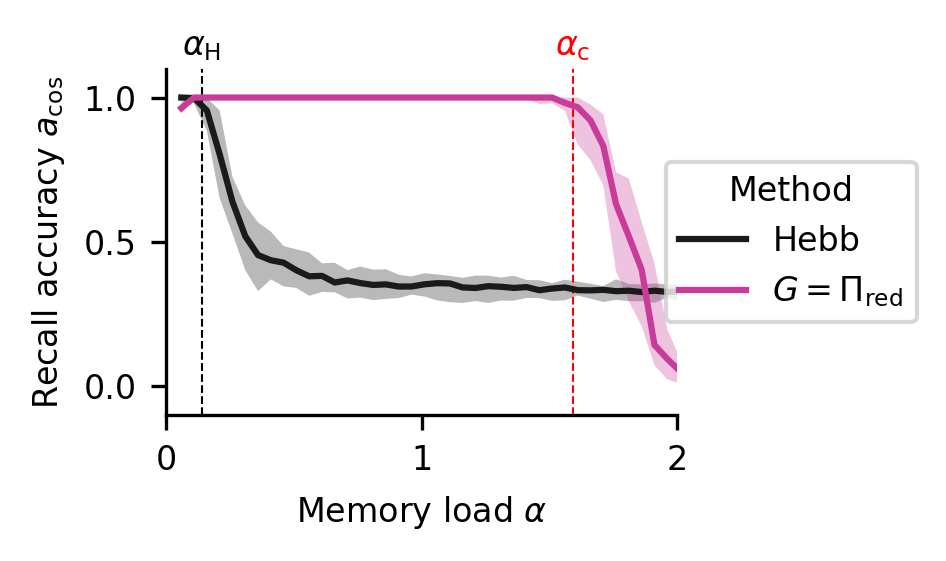

In [4]:
fig, ax = plt.subplots(1)
ax.set_prop_cycle(color=paper_palette[0:1] + paper_palette[5:6])
ax.set_xlabel(r'Memory load $\alpha$')
ax.set_ylabel(r'Recall accuracy $a_{\mathrm{cos}}$')
ax.vlines(alpha_h, -0.1, 1.1, 'k', '--', linewidth=0.5)
ax.vlines(alpha_red, -0.1, 1.1, 'r', '--', linewidth=0.5)
ax.text(alpha_h, 1 + 0.12, r'$\alpha_\mathrm{H}$',
        horizontalalignment='center', verticalalignment='bottom')
ax.text(alpha_red, 1 + 0.12, r'$\alpha_{\mathrm{c}}$',
        horizontalalignment='center', verticalalignment='bottom', c='r')

plotting.plot_mean_and_area(ax, alpha[1:], acc2[1:],
                            label='Hebb', quantile=0.9, median=True)
plotting.plot_mean_and_area(ax, alpha[1:], acc[:, 1:], mean_ax=0,
                            label=r'$G=\Pi_{\mathrm{red}}$', quantile=0.9, median=True)

plotting.layout_performance(ax, (0, 2), x_log=False, show_legend=False)
ax.legend(loc='center right', bbox_to_anchor=(1.5, 0.5), title='Method')
ax.xaxis.set_major_formatter(ScalarFormatter())
for loc, spine in ax.spines.items():
    if loc in ['right', 'top']:
        spine.set_color('none')
# fig.savefig(f"{plot_path}/capacity.svg", bbox_inches='tight')

## Panel D: PID decomposition

Shows how the PID atoms (unique, redundant, synergistic information) evolve with memory load.

**Training command:**
```bash
python src/training.py -m params.alpha='range(0.01,2.02,0.05)' \
    params.epochs=5000 params.seed='range(20)' \
    storage.final.pid=True storage=minimal
```

In [ ]:
# TODO: set path to the PID experiment folder
pid_path = ''
dm_d = datamanager.DataManager(pid_path, mode='analysis', add_run_properties=True, verbose=0)
datareader.sort_dm(dm_d, 'params.alpha')

n_reps = len(set(dm_d.sel['params.seed']))
n_neurons = dm_d.sel['params.neurons'].iloc[0]
x_alpha = dm_d.sel['params.alpha'][::n_reps]

mean_pid = datareader.pid_to_numpy(dm_d, mean=True).reshape(5, -1, n_reps)
print(f"Loaded {dm_d.all.shape[0]} runs ({n_reps} seeds, {len(x_alpha)} alpha values).")

Loaded 820 runs (20 seeds, 41 alpha values).


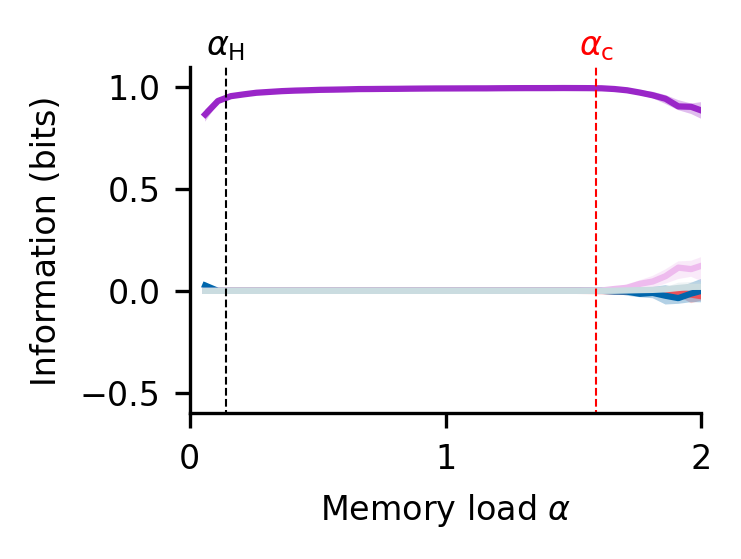

In [6]:
fig, ax = plt.subplots(1)
ax.set_xlabel(r'Memory load $\alpha$')
ax.set_ylabel(r'Information (bits)')

for i, (y, tag) in enumerate(zip(mean_pid, datareader.atom_names)):
    plotting.plot_mean_and_area(ax, x_alpha[1:], y[1:], mean_ax=1, quantile=0.9, median=True)

ax.vlines(alpha_h, -1, 2, 'k', '--', linewidth=0.5)
ax.vlines(alpha_red, -1, 2, 'r', '--', linewidth=0.5)
ax.text(alpha_h, 1 + 0.12, r'$\alpha_\mathrm{H}$',
        horizontalalignment='center', verticalalignment='bottom')
ax.text(alpha_red, 1 + 0.12, r'$\alpha_{\mathrm{c}}$',
        horizontalalignment='center', verticalalignment='bottom', c='r')
for loc, spine in ax.spines.items():
    if loc in ['right', 'top']:
        spine.set_color('none')
plotting.layout_performance(ax, x_lim=(0, 2), y_lim=(-0.5, 1), y_ticks=4, x_log=False, show_legend=False)
ax.xaxis.set_major_formatter(ScalarFormatter())
# fig.savefig(f"{plot_path}/pid_profile_median.svg", bbox_inches='tight')